# Real - Exploração Inicial

> JupyterLab configurations

In [1]:
%xmode plain

Exception reporting mode: Plain


In [2]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import ConnectionPatch

In [4]:
import time

In [5]:
import os

In [6]:
from pathlib import Path

In [7]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"

> `jupysql` configurations

In [8]:
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = True
%config SqlMagic.displaycon = True

> `duckdb` configurations

In [9]:
import duckdb
import pandas as pd

# pasta temporária pra spill
os.makedirs(".tmp", exist_ok=True)

conn = duckdb.connect("DuckDB/lab.duckdb")

# deixar uma thread pro sistema
conn.execute("SET threads = 7")

# deixa ~3 GB de ram pro OS + Jupyter
conn.execute("SET memory_limit = '13GB'")

# spill
conn.execute("SET temp_directory = '.tmp'")

# spill no máximo 10 GB
conn.execute("SET max_temp_directory_size = '10GB'")

# lê blocos maiores do disco - bom para NVMe
conn.execute("SET checkpoint_threshold = '1GB'")

In [10]:
conn.sql("""
    SELECT name, value
    FROM duckdb_settings()
    WHERE name IN (
      'threads', 'memory_limit', 'temp_directory',
      'max_temp_directory_size', 'checkpoint_threshold'
    )
""").show()

┌─────────────────────────┬───────────┐
│          name           │   value   │
│         varchar         │  varchar  │
├─────────────────────────┼───────────┤
│ checkpoint_threshold    │ 953.6 MiB │
│ max_temp_directory_size │ 9.3 GiB   │
│ memory_limit            │ 12.1 GiB  │
│ temp_directory          │ .tmp      │
│ threads                 │ 7         │
└─────────────────────────┴───────────┘



## Estrutura

In [11]:
from pathlib import Path
PAR_REAL = Path("Parquet/real_events.parquet") # 12.4 GB

WindowsPath('Parquet/real_events.parquet')

In [12]:
conn.sql(f"""
DESCRIBE SELECT *
FROM '{PAR_REAL}'
""").show()

┌─────────────┬────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │    column_type     │  null   │   key   │ default │  extra  │
│   varchar   │      varchar       │ varchar │ varchar │ varchar │ varchar │
├─────────────┼────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ _index      │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _type       │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _id         │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _score      │ BIGINT             │ YES     │ NULL    │ NULL    │ NULL    │
│ _source     │ MAP(VARCHAR, JSON) │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴────────────────────┴─────────┴─────────┴─────────┴─────────┘



A complexidade está todas nos eventos em `_source`

In [13]:
total_linhas_real = conn.sql(f"SELECT COUNT(*) FROM '{PAR_REAL}'").fetchone()[0]
print(f"{total_linhas_real = :_}")

total_linhas_real = 202_304_794


> Criar uma view pra não ficar repetindo o caminho

In [14]:
conn.execute(f"""
CREATE OR REPLACE VIEW real AS
SELECT * FROM read_parquet('{PAR_REAL}')
""");

Agora fica um tico mais legíveis as queries

In [15]:
conn.sql("DESCRIBE real")

┌─────────────┬────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │    column_type     │  null   │   key   │ default │  extra  │
│   varchar   │      varchar       │ varchar │ varchar │ varchar │ varchar │
├─────────────┼────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ _index      │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _type       │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _id         │ VARCHAR            │ YES     │ NULL    │ NULL    │ NULL    │
│ _score      │ BIGINT             │ YES     │ NULL    │ NULL    │ NULL    │
│ _source     │ MAP(VARCHAR, JSON) │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────┴────────────────────┴─────────┴─────────┴─────────┴─────────┘

> ⚠️ `_source` não tem estrutura homogênea. Tem muitas chaves diferentes

## Datapoint Normal

In [16]:
real_df_example_datapoint = conn.sql("SELECT * FROM real LIMIT 1").df()

,_index,_type,_id,_score,_source
0,logs-endpoint-winevent-additional-2022.07.01,_doc,729e39cd5007321c1ad44ef30bb9785eb7ccd296,1,"{'Status': '""3221226536""', 'z_elastic_ecs': '{..."


In [17]:
import json
import pprint

In [18]:
real_json_example_datapoint = json.loads(real_df_example_datapoint['_source'].to_json())['0'] # esse 0 é pq na Series vem o índice do valor

{'Status': '"3221226536"',
 'z_elastic_ecs': '{"agent":{},"ecs":{"version":"8.0.0"},"host":{},"log":{},"winlog":{"process":{"thread":{}}},"event":{"kind":"event","code":"3033","provider":"Microsoft-Windows-CodeIntegrity","action":"CreateSection","created":"2022-07-01T06:26:39.218Z"},"user":{"type":"Well Known Group","domain":"NT AUTHORITY","name":"Servicio de red","identifier":"S-1-5-20"}}',
 '@version': '"1"',
 'FileNameBuffer': '"\\\\Device\\\\HarddiskVolume2\\\\Program Files\\\\Bonjour\\\\mdnsNSP.dll"',
 'type': '"wineventlog"',
 'record_number': '50674',
 'host_name': '"computer03.domain.es"',
 'ProcessNameBuffer': '"\\\\Device\\\\HarddiskVolume2\\\\Windows\\\\System32\\\\svchost.exe"',
 'process_id': '9644',
 'ValidatedPolicy': '"1"',
 'provider_guid': '"4ee76bd8-3cf4-44a0-a0ac-3937643e37a3"',
 'level': '"error"',
 'etl_version': '"2020.04.19.01"',
 'ProcessNameLength': '"52"',
 'beat_name': '"computer03"',
 'etl_host_agent_type': '"winlogbeat"',
 'etl_host_agent_ephemeral_uid': '

## Datapoint Malicioso

Os maliciosos estão associados ao MITRE ATT&CK

In [19]:
# contar maliciosos
real_df_count_malicious = conn.sql("""
    SELECT COUNT(*) AS maliciosos
    FROM real
    WHERE _source['rule_technique_id'] IS NOT NULL
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,maliciosos
0,631606


In [20]:
real_count_malicious = f"{real_df_count_malicious['maliciosos'][0]:,}"

'631,606'

In [21]:
# exemplo de datapoint malicioso
real_df_example_malicious_datapoint = conn.sql("""
    SELECT *
    FROM real
    WHERE _source['rule_technique_id'] IS NOT NULL
    LIMIT 1
""").df()

,_index,_type,_id,_score,_source
0,logs-endpoint-winevent-sysmon-2022.06.27,_doc,5b500a180e4bbf4fb6368bb65e3b5878ca17342b,1,"{'user_name': '""system""', 'Description': '""Mic..."


In [22]:
real_json_example_malicious_datapoint = json.loads(real_df_example_malicious_datapoint['_source'].to_json())['0'] # esse 0 é pq na Series vem o índice do valor
pprint.pprint(real_json_example_malicious_datapoint, sort_dicts=True)

{'@timestamp': '"2022-06-27T06:54:22.310Z"',
 '@version': '"1"',
 'Company': '"Microsoft Corporation"',
 'Description': '"Microsoft .NET Runtime Execution Engine"',
 'FileVersion': '"4.8.4180.0 built by: NET48REL1LAST_B"',
 'ImageLoaded': '"c:\\\\windows\\\\microsoft.net\\\\framework64\\\\v4.0.30319\\\\mscoreei.dll"',
 'OriginalFileName': '"mscoreei.dll"',
 'Product': '"Microsoft® .NET Framework"',
 'RuleName': '"technique_id=T1055,technique_name=Process Injection"',
 'Signature': '"Microsoft Corporation"',
 'SignatureStatus': '"Valid"',
 'Signed': '"true"',
 'beat_name': '"computer15"',
 'beat_version': '"8.2.1"',
 'etl_host_agent_ephemeral_uid': '"70c56499-45c9-408b-ab87-87880d323289"',
 'etl_host_agent_type': '"winlogbeat"',
 'etl_host_agent_uid': '"1076fa0e-355b-427e-a362-97dac46ed498"',
 'etl_pipeline': '["all-filter-0098","all-add_processed_timestamp","fingerprint-winlogbeats7","winlogbeat_7_and_above-field_nest_cleanup","winlogbeat_7_and_above-field_cleanups","1500","1522","wine

## Chaves presentes no mapa chave-valor

### Tabela `real_field_presence`

In [23]:
conn.execute(f"""
CREATE OR REPLACE TABLE real_field_presence AS
WITH campos_expandidos AS (
    SELECT unnest(map_keys(_source)) AS campo
    FROM real
),
agregado AS (
    SELECT
        campo,
        COUNT(*) AS n_eventos
    FROM campos_expandidos
    GROUP BY campo
)
SELECT
    campo,
    n_eventos,
    printf('%,d', n_eventos) AS n_eventos_fmt,

    -- percentual com precisão alta
    CAST(100 * n_eventos AS DECIMAL(18,5)) / {total_linhas_real} AS percentual_raw,

    -- versão arredondada só pra leitura
    round(
        CAST(100 * n_eventos AS DECIMAL(18,5)) / {total_linhas_real}, 2
    ) AS percentual

FROM agregado
ORDER BY n_eventos DESC, campo
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Salvando-a em disco

In [24]:
conn.execute("""
COPY real_field_presence
TO 'Comiset23_Real_Dataset/real_field_presence.csv'
(FORMAT CSV)
""")

### Campos e suas presenças

In [25]:
conn.sql("""
SELECT campo, n_eventos_fmt, percentual, percentual_raw
FROM real_field_presence
ORDER BY n_eventos DESC
""").show(max_rows=1500)

┌─────────────────────────────────────────────────────────────────────┬───────────────┬────────────┬────────────────────────┐
│                                campo                                │ n_eventos_fmt │ percentual │     percentual_raw     │
│                               varchar                               │    varchar    │   double   │         double         │
├─────────────────────────────────────────────────────────────────────┼───────────────┼────────────┼────────────────────────┤
│ @timestamp                                                          │ 202,304,794   │      100.0 │                  100.0 │
│ @version                                                            │ 202,304,794   │      100.0 │                  100.0 │
│ beat_name                                                           │ 202,304,794   │      100.0 │                  100.0 │
│ beat_version                                                        │ 202,304,794   │      100.0 │                  

### Anotando categorias semânticas

Claude ajudou a separar, dados os 897 campos

In [26]:
result_real_annotated = conn.sql("""
    SELECT
        campo,
        n_eventos_fmt,
        percentual,
        CASE
            WHEN campo IN ('@timestamp','event_original_time','event_recorded_time','event_timezone')
                THEN 'tempo'
            WHEN campo IN ('event_id','log_name','source_name','level','opcode','record_number',
                           'version','task','xml_name','activity_id','keywords')
                THEN 'evento_windows'
            WHEN campo IN ('process_name','process_path','process_id','process_guid',
                           'process_parent_name','process_parent_path','process_parent_id',
                           'process_parent_guid','target_process_name','target_process_path',
                           'target_process_id','target_process_guid',
                           'CommandLine','ParentCommandLine','CurrentDirectory','IntegrityLevel',
                           'ProcessCreationTime','CallTrace','GrantedAccess','SourceThreadId',
                           'StartAddress','StartModule','StartFunction','NewThreadId',
                           'SourceUser','TargetUser','ProcessID','ProcessCommandLine',
                           'ProcessCommandLineLength','ProcessPathLength',
                           'ImageName','ImageNameLength','ProcessCreateTime',
                           'ProcessProtection','ProcessSectionSignatureLevel',
                           'ProcessSignatureLevel','ProcessStartKey',
                           'TargetThreadCreateTime','TargetThreadId',
                           'CallingProcessId','CallingProcessCreateTime',
                           'CallingProcessProtection','CallingProcessSignatureLevel',
                           'CallingThreadId','CallingThreadCreateTime')
                THEN 'processo'
            WHEN campo IN ('user_name','user_domain','user_account','user_sid','user_logon_id',
                           'meta_user_name_is_machine','LogonId','LogonGuid','logon_type',
                           'SubjectUserName','SubjectDomainName','SubjectUserSid','SubjectLogonId',
                           'TargetUserName','TargetDomainName','TargetUserSid','TargetLogonId',
                           'AuthenticationPackageName','ElevatedToken','ImpersonationLevel',
                           'UserName','User','UserContext')
                THEN 'identidade'
            WHEN campo IN ('src_ip_addr','dst_ip_addr','DestinationPort','SourcePort','Protocol',
                           'DestinationHostname','SourceHostname','Initiated','PipeName',
                           'src_ip_public','dst_ip_public','src_ip_rfc','dst_ip_rfc',
                           'QueryName','QueryResults','QueryStatus',
                           'dst_ip_type','dst_ip_version','dst_is_ipv6',
                           'src_ip_type','src_ip_version','src_is_ipv6',
                           'DestinationIsIpv6','SourceIsIpv6',
                           'DestinationPortName','SourcePortName')
                THEN 'rede'
            WHEN campo IN ('TargetFilename','file_creation_time','file_previous_creation_time',
                           'TargetObject','EventType','Details','ImageLoaded',
                           'hash_md5','hash_sha1','hash_sha256','hash_imphash','Hash',
                           'Signature','SignatureStatus','Signed',
                           'IsExecutable','Archived','Description','Company',
                           'FileVersion','OriginalFileName','Product',
                           'FileNameBuffer','FileNameLength')
                THEN 'arquivo_registro'
            WHEN campo IN ('rule_technique_id','rule_technique_name','rule_technique',
                           'RuleName','RuleId','tags')
                THEN 'mitre_label'
            WHEN campo IN ('host_name','beat_name','beat_version','provider_guid','thread_id',
                           'process_id','ProductId','CorrelationVector')
                THEN 'host_sistema'
            WHEN campo LIKE 'etl_%'
                OR campo IN ('@version','z_elastic_ecs','z_logstash_pipeline',
                             'etl_pipeline','etl_version','etl_processed_time',
                             'etl_host_agent_type','etl_host_agent_uid',
                             'etl_host_agent_ephemeral_uid','event_original_message')
                THEN 'etl_infraestrutura'
            WHEN campo LIKE 'param%'
                OR campo LIKE 'BucketIo%'
                OR campo LIKE 'Mft%'
                OR campo LIKE 'LastError_%'
                OR campo LIKE 'TotalDevice%'
                OR campo LIKE 'BugcheckP%'
                OR campo LIKE 'LogFileFull%'
                OR campo LIKE 'MetaData%'
                OR campo LIKE 'UserDisk%'
                OR campo LIKE 'UserFile%'
                OR campo LIKE 'UserIndex%'
                OR campo LIKE 'VolumeTrim%'
                OR campo LIKE 'DeviceQueue%'
                OR campo LIKE 'FlushLatency%'
                OR campo LIKE 'ReadWriteLatency%'
                OR campo LIKE 'TrimLatency%'
                OR campo LIKE 'Vcb%'
                OR campo LIKE 'Directory%'
                OR campo LIKE 'FileLevelTrim%'
                OR campo LIKE 'SmartA%'
                OR campo LIKE 'NCRead%'
                OR campo LIKE 'NCWrite%'
                OR campo LIKE 'LastError%'
                OR campo LIKE 'BucketIoLatency%'
                OR campo LIKE 'BucketIoSuccess%'
                THEN 'ruido_hardware'
            ELSE 'outros'
        END AS categoria,
        CASE
            WHEN campo IN ('process_guid','target_process_guid',
                           '@timestamp','event_id','host_name',
                           'rule_technique_id','rule_technique_name',
                           'process_name','CommandLine','LogonId',
                           'SourceUser','TargetUser','CallTrace','GrantedAccess')
                THEN true ELSE false
        END AS pm_core,
        CASE
            WHEN campo IN ('rule_technique_id','rule_technique_name','event_id','host_name',
                           'process_name','process_path','SourceUser','TargetUser',
                           'CommandLine','src_ip_addr','dst_ip_addr','DestinationPort',
                           'hash_md5','hash_sha256','IntegrityLevel','logon_type',
                           'TargetFilename','CallTrace','GrantedAccess',
                           'target_process_name','target_process_id')
                THEN true ELSE false
        END AS ml_feature
    FROM real_field_presence
    ORDER BY
        CASE categoria
            WHEN 'mitre_label'        THEN 1
            WHEN 'processo'           THEN 2
            WHEN 'identidade'         THEN 3
            WHEN 'rede'               THEN 4
            WHEN 'arquivo_registro'   THEN 5
            WHEN 'tempo'              THEN 6
            WHEN 'evento_windows'     THEN 7
            WHEN 'host_sistema'       THEN 8
            WHEN 'outros'             THEN 9
            WHEN 'etl_infraestrutura' THEN 10
            WHEN 'ruido_hardware'     THEN 11
        END,
        percentual DESC
""")

result_real_annotated.write_csv('Comiset23_Real_Dataset/real_field_presence_annotated.csv')
result_real_annotated.show(max_rows=1500)

┌─────────────────────────────────────────────────────────────────────┬───────────────┬────────────┬────────────────────┬─────────┬────────────┐
│                                campo                                │ n_eventos_fmt │ percentual │     categoria      │ pm_core │ ml_feature │
│                               varchar                               │    varchar    │   double   │      varchar       │ boolean │  boolean   │
├─────────────────────────────────────────────────────────────────────┼───────────────┼────────────┼────────────────────┼─────────┼────────────┤
│ RuleName                                                            │ 202,259,235   │      99.98 │ mitre_label        │ false   │ false      │
│ rule_technique_name                                                 │ 631,703       │       0.31 │ mitre_label        │ true    │ true       │
│ rule_technique_id                                                   │ 631,606       │       0.31 │ mitre_label        │ true    

### Tentando separar em 'bins'

In [27]:
real_field_presence_bins_semantic = conn.sql("""
SELECT
    campo,
    percentual,
    CASE
        WHEN percentual >= 99 THEN '99–100%'
        WHEN percentual >= 90 THEN '90–99%'
        WHEN percentual >= 50 THEN '50–90%'
        WHEN percentual >= 10 THEN '10–50%'
        WHEN percentual >= 1 THEN '1–10%'
        ELSE '<1%'
    END AS bin,
    n_eventos
FROM real_field_presence
""").show(max_rows=1500)

┌─────────────────────────────────────────────────────────────────────┬────────────┬─────────┬───────────┐
│                                campo                                │ percentual │   bin   │ n_eventos │
│                               varchar                               │   double   │ varchar │   int64   │
├─────────────────────────────────────────────────────────────────────┼────────────┼─────────┼───────────┤
│ @timestamp                                                          │      100.0 │ 99–100% │ 202304794 │
│ @version                                                            │      100.0 │ 99–100% │ 202304794 │
│ beat_name                                                           │      100.0 │ 99–100% │ 202304794 │
│ beat_version                                                        │      100.0 │ 99–100% │ 202304794 │
│ etl_host_agent_ephemeral_uid                                        │      100.0 │ 99–100% │ 202304794 │
│ etl_host_agent_type                

In [28]:
real_field_presence_bins_semantic_summary = conn.sql("""
SELECT
    CASE
        WHEN percentual >= 99 THEN '99–100%'
        WHEN percentual >= 90 THEN '90–99%'
        WHEN percentual >= 50 THEN '50–90%'
        WHEN percentual >= 10 THEN '10–50%'
        WHEN percentual >= 1 THEN '1–10%'
        ELSE '<1%'
    END AS bin,
    COUNT(*) AS n_campos
FROM real_field_presence
GROUP BY 1
ORDER BY
    CASE bin
        WHEN '99–100%' THEN 1
        WHEN '90–99%' THEN 2
        WHEN '50–90%' THEN 3
        WHEN '10–50%' THEN 4
        WHEN '1–10%' THEN 5
        ELSE 6
    END
""")

┌─────────┬──────────┐
│   bin   │ n_campos │
│ varchar │  int64   │
├─────────┼──────────┤
│ 99–100% │       41 │
│ <1%     │      856 │
└─────────┴──────────┘

### Histograma das frequências

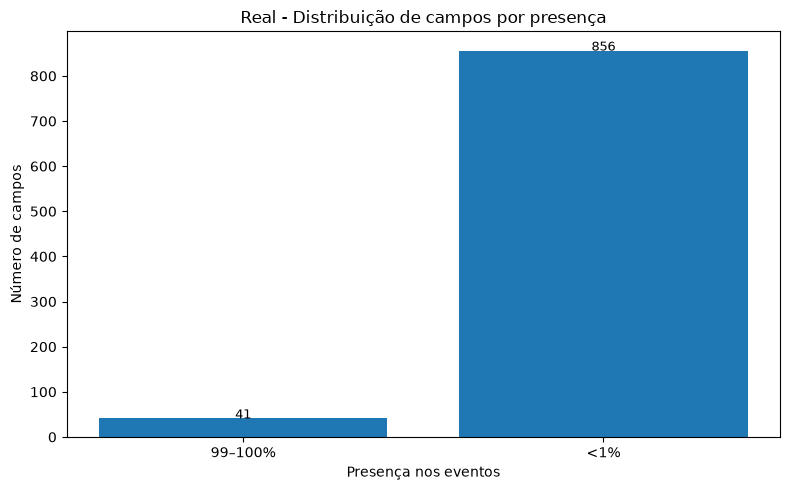

In [29]:
real_df_field_presence_summary = real_field_presence_bins_semantic_summary.df()
plt.figure(figsize=(8, 5))
plt.bar(real_df_field_presence_summary['bin'], real_df_field_presence_summary['n_campos'])
# plt.yscale('log')  # se quiser deixar um pouco mais aparentes as barras
plt.xlabel('Presença nos eventos')
plt.ylabel('Número de campos')
plt.title('Real - Distribuição de campos por presença')
for i, v in enumerate(real_df_field_presence_summary['n_campos']):
    plt.text(i, v, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---

## Técnicas Presentes

In [30]:
# confirmar os labels MITRE — quais técnicas existem no real
t0 = time.perf_counter()
result = conn.sql("""
    SELECT
        _source['rule_technique_id']::VARCHAR   AS tecnica_id,
        _source['rule_technique_name']::VARCHAR AS tecnica_nome,
        printf('%,d', COUNT(*)) AS n_fmt,
        COUNT(*) AS n
    FROM real
    WHERE _source['rule_technique_id'] IS NOT NULL
    GROUP BY 1, 2
    ORDER BY n DESC
""")
result.write_csv("Comiset23_Real_Dataset/real_mitre_techniques.csv")
result.show(max_rows=100)
print(f"{time.perf_counter() - t0:.1f}s")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────┬─────────────────────────────────────────────────────┬─────────┬────────┐
│   tecnica_id    │                    tecnica_nome                     │  n_fmt  │   n    │
│     varchar     │                       varchar                       │ varchar │ int64  │
├─────────────────┼─────────────────────────────────────────────────────┼─────────┼────────┤
│ "T1055"         │ "Process Injection"                                 │ 517,395 │ 517395 │
│ "T1055.001"     │ "Dynamic-link Library Injection"                    │ 35,633  │  35633 │
│ "T1543"         │ "Service Creation"                                  │ 32,224  │  32224 │
│ "T1003"         │ "Credential Dumping"                                │ 12,083  │  12083 │
│ "T1053"         │ "Scheduled Task"                                    │ 7,237   │   7237 │
│ "T1093"         │ "Process Hollowing"                                 │ 5,303   │   5303 │
│ "T1130"         │ "Install Root Certificate"                        

## Distribuição de RuleName

In [31]:
t0 = time.perf_counter()
df_real_rulename = conn.sql("""
    SELECT
        _source['RuleName']::VARCHAR AS rule_name,
        COUNT(*) AS n,
        printf('%,d', COUNT(*)) AS n_fmt,
        round(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM real
    WHERE _source['RuleName'] IS NOT NULL
    GROUP BY 1
    ORDER BY n DESC
    LIMIT 30
""").df()
print(f"{time.perf_counter() - t0:.1f}s")
df_real_rulename.to_csv("Comiset23_Real_Dataset/real_mitre_rulename_distribution.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

395.7s


In [32]:
print(df_real_rulename[['rule_name', 'n_fmt', 'pct']].to_string())

                                                                                    rule_name        n_fmt   pct
0                                                                                         "-"  201,627,319 99.69
1                                       "technique_id=T1055,technique_name=Process Injection"      517,395  0.26
2                      "technique_id=T1055.001,technique_name=Dynamic-link Library Injection"       35,633  0.02
3                                        "technique_id=T1543,technique_name=Service Creation"       32,224  0.02
4                                      "technique_id=T1003,technique_name=Credential Dumping"       12,083  0.01
5                                          "technique_id=T1053,technique_name=Scheduled Task"        7,237  0.00
6                                       "technique_id=T1093,technique_name=Process Hollowing"        5,303  0.00
7                                "technique_id=T1130,technique_name=Install Root Certificate"   

## Distribuição de EventID

In [33]:
real_df_eventid = conn.sql("""
    SELECT
        trim('"' FROM _source['event_id']::VARCHAR)        AS event_id,
        trim('"' FROM _source['log_name']::VARCHAR)        AS canal,
        trim('"' FROM _source['source_name']::VARCHAR)     AS provedor,
        COUNT(*)                                           AS n,
        COUNT(*) FILTER (
            WHERE _source['rule_technique_id'] IS NOT NULL
        )                                                  AS n_maliciosos
    FROM real
    GROUP BY 1, 2, 3
    ORDER BY n DESC
""").df()

real_df_eventid['pct']           = (real_df_eventid['n'] / real_df_eventid['n'].sum() * 100).round(2)
real_df_eventid['pct_malicioso'] = (real_df_eventid['n_maliciosos'] / real_df_eventid['n'] * 100).round(2)
real_df_eventid['n_fmt']         = real_df_eventid['n'].apply(lambda x: f"{x:,}")

print(f"EventIDs únicos: {len(real_df_eventid)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

EventIDs únicos: 313


In [34]:
real_df_eventid

,event_id,canal,provedor,n,n_maliciosos,pct,pct_malicioso,n_fmt
0,10,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,200916113,53765,99.31,0.03,"200,916,113"
1,7,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,525091,523812,0.26,99.76,"525,091"
2,11,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,337375,4,0.17,0.00,"337,375"
3,12,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,302452,29793,0.15,9.85,"302,452"
4,13,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,91205,18672,0.05,20.47,"91,205"
...,...,...,...,...,...,...,...,...
308,3,Microsoft-Windows-Store/Operational,Windows-ApplicationModel-Store-SDK,1,0,0.00,0.00,1
309,1001,Application,SceCli,1,0,0.00,0.00,1
310,30805,Microsoft-Windows-SmbClient/Connectivity,Microsoft-Windows-SMBClient,1,0,0.00,0.00,1
311,430,Microsoft-Windows-Kernel-PnP/Configuration,Microsoft-Windows-Kernel-PnP,1,0,0.00,0.00,1


In [35]:
real_df_eventid.to_csv("Comiset23_Real_Dataset/real_eventid_distribution.csv")

In [36]:
# nomes semânticos dos EventIDs Sysmon + Windows mais comuns
SYSMON_NAMES = {
    '1':  'Sysmon 1\nProcess Creation',
    '2':  'Sysmon 2\nFile Creation Time',
    '3':  'Sysmon 3\nNetwork Connection',
    '5':  'Sysmon 5\nProcess Terminated',
    '6':  'Sysmon 6\nDriver Loaded',
    '7':  'Sysmon 7\nImage Loaded',
    '8':  'Sysmon 8\nCreateRemoteThread',
    '9':  'Sysmon 9\nRawAccessRead',
    '10': 'Sysmon 10\nProcessAccess',
    '11': 'Sysmon 11\nFileCreate',
    '12': 'Sysmon 12\nRegistry Create/Delete',
    '13': 'Sysmon 13\nRegistry SetValue',
    '14': 'Sysmon 14\nRegistry Rename',
    '15': 'Sysmon 15\nFileCreateStreamHash',
    '17': 'Sysmon 17\nPipe Created',
    '18': 'Sysmon 18\nPipe Connected',
    '22': 'Sysmon 22\nDNS Query',
    '23': 'Sysmon 23\nFileDelete',
    '25': 'Sysmon 25\nProcessTampering',
    '4624': 'WinSec 4624\nLogon Success',
    '4625': 'WinSec 4625\nLogon Failure',
    '4688': 'WinSec 4688\nProcess Created',
    '4663': 'WinSec 4663\nObject Access',
    '5858': 'WMI 5858\nQuery Failure',
}

# agrupa: top-N com pct > 0.1%, resto em "outros"
THRESH = 0.1
df_top = real_df_eventid[real_df_eventid['pct'] >= THRESH].copy()
df_outros = real_df_eventid[real_df_eventid['pct'] < THRESH]

outros_row = {
    'event_id':      'outros',
    'provedor':      f'{len(df_outros)} event_ids',
    'n':             df_outros['n'].sum(),
    'n_maliciosos':  df_outros['n_maliciosos'].sum(),
    'pct':           df_outros['pct'].sum().round(3),
    'pct_malicioso': (df_outros['n_maliciosos'].sum() / df_outros['n'].sum() * 100).round(2),
    'n_fmt':         f"{df_outros['n'].sum():,}",
}
real_df_eventid_plot = pd.concat(
    [df_top, pd.DataFrame([outros_row])], ignore_index=True
)

real_df_eventid_plot['label'] = real_df_eventid_plot['event_id'].map(
    lambda x: SYSMON_NAMES.get(x, f'EID {x}')
)
real_df_eventid_plot = real_df_eventid_plot.sort_values('pct_malicioso', ascending=True)
real_df_eventid_plot

,event_id,canal,provedor,n,n_maliciosos,pct,pct_malicioso,n_fmt,label
2,11,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,337375,4,0.17,0.00,"337,375",Sysmon 11\nFileCreate
0,10,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,200916113,53765,99.31,0.03,"200,916,113",Sysmon 10\nProcessAccess
3,12,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,302452,29793,0.15,9.85,"302,452",Sysmon 12\nRegistry Create/Delete
4,outros,NaN,309 event_ids,223763,24232,0.09,10.83,"223,763",EID outros
1,7,Microsoft-Windows-Sysmon/Operational,Microsoft-Windows-Sysmon,525091,523812,0.26,99.76,"525,091",Sysmon 7\nImage Loaded


In [37]:
mean_pct_malicious = round(real_df_eventid_plot["pct_malicioso"].mean(), 2)

np.float64(24.09)

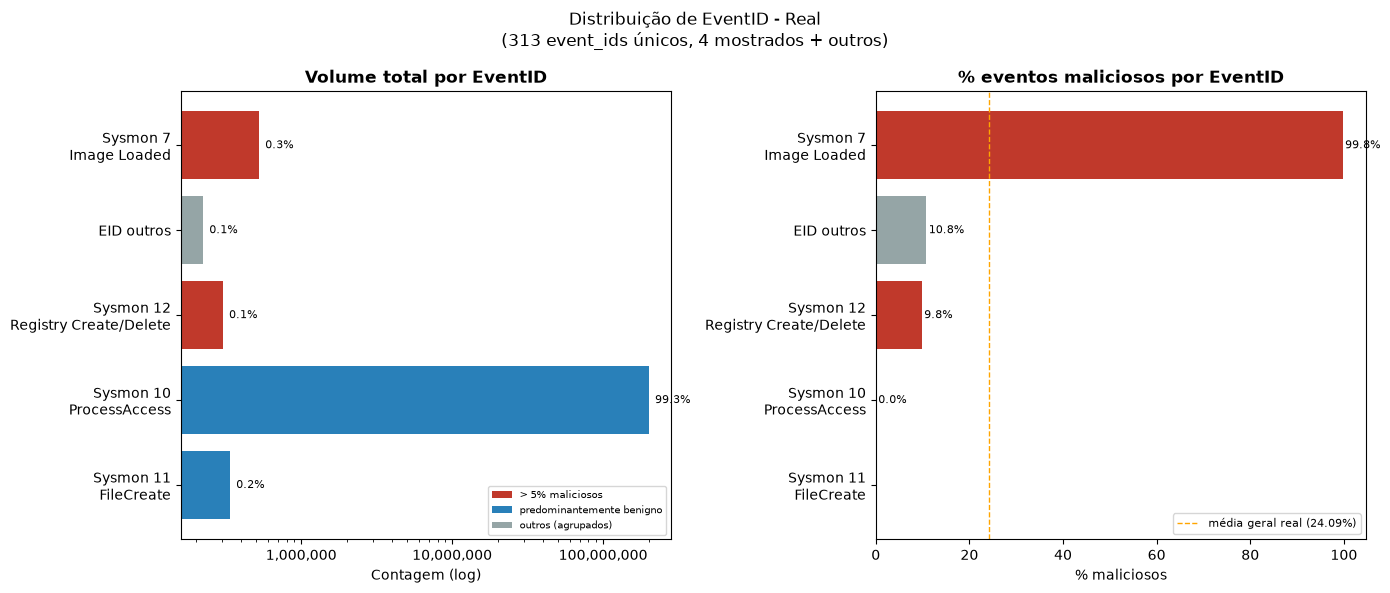

In [38]:
# --- figura ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# cores: vermelho se malicioso > 5%, azul normal, cinza = outros
def cor(row):
    if row['event_id'] == 'outros':
        return '#95a5a6'
    if row['pct_malicioso'] > 5:
        return '#c0392b'
    return '#2980b9'

colors = [cor(row) for _, row in real_df_eventid_plot.iterrows()]

# ax1 - volume total
bars = ax1.barh(real_df_eventid_plot['label'], real_df_eventid_plot['n'], color=colors)
ax1.set_xscale('log')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.set_title('Volume total por EventID', fontweight='bold')
ax1.set_xlabel('Contagem (log)')
for bar, row in zip(bars, real_df_eventid_plot.itertuples()):
    ax1.text(row.n * 1.1, bar.get_y() + bar.get_height()/2,
             f"{row.pct:.1f}%", va='center', fontsize=8)

# ax2 - taxa de maliciosidade
bars2 = ax2.barh(real_df_eventid_plot['label'], real_df_eventid_plot['pct_malicioso'],
                 color=colors)
ax2.set_title('% eventos maliciosos por EventID', fontweight='bold')
ax2.set_xlabel('% maliciosos')
ax2.axvline(x=mean_pct_malicious, color='orange', linestyle='--', lw=1,
            label=f'média geral real ({mean_pct_malicious}%)')
ax2.legend(fontsize=8)
for bar, row in zip(bars2, real_df_eventid_plot.itertuples()):
    if row.pct_malicioso > 0:
        ax2.text(row.pct_malicioso + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{row.pct_malicioso:.1f}%", va='center', fontsize=8)

# legenda de cores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#c0392b', label='> 5% maliciosos'),
    Patch(facecolor='#2980b9', label='predominantemente benigno'),
    Patch(facecolor='#95a5a6', label='outros (agrupados)'),
]
ax1.legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.suptitle('Distribuição de EventID - Real\n'
             f'({len(real_df_eventid)} event_ids únicos, {len(real_df_eventid_plot)-1} mostrados + outros)',
             fontsize=12)
plt.tight_layout()
plt.savefig('Comiset23_Real_Dataset/real_eventid_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Distribuição de EventType

In [39]:
t0 = time.perf_counter()
result_eventtype_distribution = conn.sql("""
SELECT
    CAST(_source['EventType'] AS VARCHAR),
    COUNT(*) AS n
FROM real
GROUP BY 1
ORDER BY n DESC
""")
result_eventtype_distribution.write_csv("Comiset23_Real_Dataset/real_eventtype_distribution.csv")
print(f"{time.perf_counter() - t0:.1f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

392.8


In [40]:
df_eventtype_distribution = result_eventtype_distribution.df()
df_eventtype_distribution.columns = ['event_type', 'n']
df_eventtype_distribution['event_type'] = (
    df_eventtype_distribution['event_type']
    .str.strip('"') # tirando aspas do JSON
)
df_eventtype_distribution['n_fmt'] = df_eventtype_distribution['n'].apply(lambda x: f"{x:,}")
df_eventtype_distribution['pct'] = (df_eventtype_distribution['n'] / df_eventtype_distribution['n'].sum() * 100).round(2)
df_eventtype_distribution

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,n,n_fmt,pct
0,NaN,201883292,"201,883,292",99.79
1,CreateKey,295118,"295,118",0.15
2,SetValue,91205,"91,205",0.05
3,ConnectPipe,20384,"20,384",0.01
4,CreatePipe,7461,"7,461",0.00
5,DeleteKey,5496,"5,496",0.00
6,DeleteValue,1838,"1,838",0.00


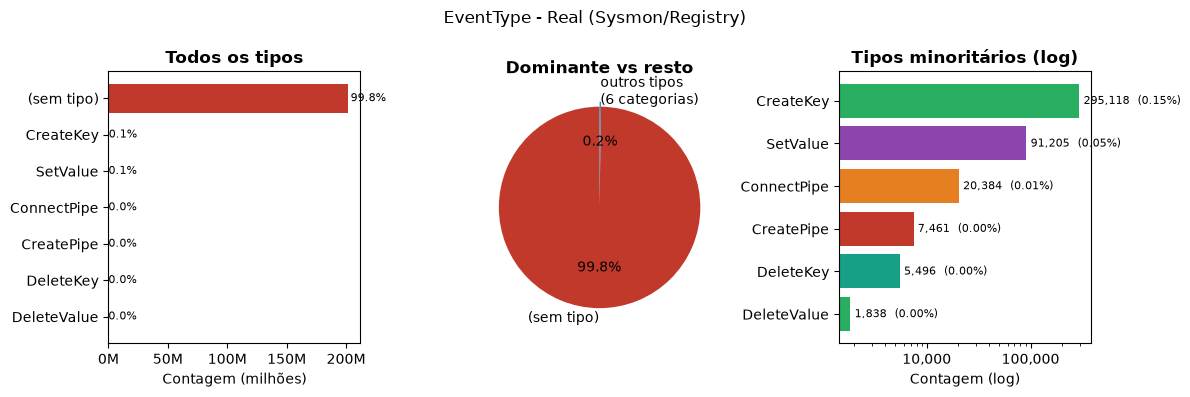

In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

df = df_eventtype_distribution.copy()
df['event_type'] = df['event_type'].fillna('(sem tipo)')

# dominante é só o (sem tipo) aqui
# pega o maior e separa o resto
dominante = df.nlargest(1, 'n')
pequenos  = df[~df['event_type'].isin(dominante['event_type'])]

fmt_m = ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')

# --- 1. barra geral ---
colors_all = ['#c0392b' if t == '(sem tipo)' else '#2980b9' for t in df['event_type']]
ax1.barh(df['event_type'], df['n'], color=colors_all)
ax1.invert_yaxis()
ax1.set_title('Todos os tipos', fontweight='bold')
ax1.set_xlabel('Contagem (milhões)')
ax1.xaxis.set_major_formatter(fmt_m)
for i, row in enumerate(df.itertuples()):
    ax1.text(row.n * 1.01, i, f"{row.pct:.1f}%", va='center', fontsize=8)

# --- 2. pizza: dominante vs todos os outros ---
outros_n   = pequenos['n'].sum()
outros_pct = outros_n / df['n'].sum() * 100
dom_pct    = dominante['pct'].values[0]
ax2.pie(
    [dominante['n'].values[0], outros_n],
    labels=[dominante['event_type'].values[0], f'outros tipos\n({len(pequenos)} categorias)'],
    colors=['#c0392b', '#2980b9'],
    startangle=90,
    autopct=lambda p: f"{p * df['n'].sum() / df['n'].sum():.1f}%",
    explode=[0, 0.05]
)
ax2.set_title(f'Dominante vs resto', fontweight='bold')

# --- 3. barra minoritários com log scale pois SetValue >> DeleteValue ---
colors_min = ['#27ae60', '#8e44ad', '#e67e22', '#c0392b', '#16a085']
ax3.barh(pequenos['event_type'], pequenos['n'],
         color=colors_min[:len(pequenos)])
ax3.invert_yaxis()
ax3.set_xscale('log')
ax3.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.set_title('Tipos minoritários (log)', fontweight='bold')
ax3.set_xlabel('Contagem (log)')
for i, row in enumerate(pequenos.itertuples()):
    ax3.text(row.n * 1.1, i, f"{row.n_fmt}  ({row.pct:.2f}%)", va='center', fontsize=8)

plt.suptitle('EventType - Real (Sysmon/Registry)', fontsize=12)
plt.tight_layout()
plt.savefig('Comiset23_Real_Dataset/real_eventtype_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Distintos aproximados

In [42]:
result_approx_distinct = conn.sql("""
    SELECT
        'real' AS dataset,
        approx_count_distinct(_source['host_name'])           AS hosts_unicos,
        approx_count_distinct(_source['user_name'])           AS users_unicos,
        approx_count_distinct(_source['event_id'])            AS event_ids_unicos,
        approx_count_distinct(_source['process_name'])        AS processos_unicos,
        approx_count_distinct(_source['rule_technique_id'])   AS tecnicas_mitre,
        approx_count_distinct(_source['log_name'])            AS canais_log,
        approx_count_distinct(_source['process_guid'])        AS sessoes_processo,
        approx_count_distinct(_source['user_account'])        AS contas_unicas,
        approx_count_distinct(_source['src_ip_addr'])         AS ips_origem_unicos,
        approx_count_distinct(_source['dst_ip_addr'])         AS ips_destino_unicos
    FROM real
""")

result_approx_distinct.write_csv("Comiset23_Real_Dataset/real_approx_distinct.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [43]:
# transpor fica mais legível que uma linha larga
real_df_approx_distinct = result_approx_distinct.df().T.reset_index()
real_df_approx_distinct.columns = ['metrica', 'valor']

# remove a linha 'dataset' que é string
real_df_approx_distinct = real_df_approx_distinct[real_df_approx_distinct['metrica'] != 'dataset']

real_df_approx_distinct['valor'] = real_df_approx_distinct['valor'].astype(int)
real_df_approx_distinct['valor_fmt'] = real_df_approx_distinct['valor'].apply(lambda x: f"{x:,}")
real_df_approx_distinct.sort_values('valor')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metrica,valor,valor_fmt
2,users_unicos,14,14
9,ips_origem_unicos,17,17
1,hosts_unicos,18,18
8,contas_unicas,23,23
6,canais_log,50,50
5,tecnicas_mitre,56,56
10,ips_destino_unicos,90,90
3,event_ids_unicos,237,237
4,processos_unicos,489,489
7,sessoes_processo,213696,"213,696"


---

## Fatia das primeiras 24 horas

### Intervalo de Tempo

In [44]:
t0 = time.perf_counter()
real_df_time_range = conn.sql("""
    SELECT
        MIN(TRIM(BOTH '"' FROM _source['@timestamp']::VARCHAR)::TIMESTAMP) AS ts_min,
        MAX(TRIM(BOTH '"' FROM _source['@timestamp']::VARCHAR)::TIMESTAMP) AS ts_max
    FROM real
""").df()
real_df_time_range['duracao'] = real_df_time_range['ts_max'] - real_df_time_range['ts_min']
print(f"{time.perf_counter() - t0:.1f}s")
real_df_time_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

317.7s


,ts_min,ts_max,duracao
0,2022-06-27 05:47:17.940,2022-07-20 12:33:29.676,23 days 06:46:11.736000


In [45]:
real_ts_min = real_df_time_range['ts_min'][0]
real_ts_cutoff_24h = real_ts_min + pd.Timedelta(hours=24)
print(f"Início:        {real_ts_min}")
print(f"Corte (24h):   {real_ts_cutoff_24h}")
print(f"Fim dataset:   {real_df_time_range['ts_max'][0]}")
print(f"Duração total: {real_df_time_range['duracao'][0]}")

Início:        2022-06-27 05:47:17.940000
Corte (24h):   2022-06-28 05:47:17.940000
Fim dataset:   2022-07-20 12:33:29.676000
Duração total: 23 days 06:46:11.736000


## Corte do 1º dia

In [46]:
D1_INICIO = '2022-06-27T05:47:17'
D1_FIM    = '2022-06-28T05:47:17'

t0 = time.perf_counter()
conn.execute(f"""
    COPY (
        SELECT *
        FROM real
        WHERE _source['@timestamp']::VARCHAR >= '"{D1_INICIO}'
          AND _source['@timestamp']::VARCHAR <  '"{D1_FIM}'
    )
    TO 'Comiset23_Real_Dataset/real_d1.parquet'
    (FORMAT PARQUET, CODEC 'ZSTD', COMPRESSION_LEVEL 9)
""")
elapsed = time.perf_counter() - t0

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

3114.9745855

In [47]:
minutes, seconds = divmod(int(elapsed), 60)
print(f"{minutes}min{seconds}s - {Path('Comiset23_Real_Dataset/real_d1.parquet').stat().st_size/1e6:.1f} MB")

51min54s - 1361.8 MB


---

### Quantidade de maliciosos

In [48]:
t0 = time.perf_counter()
real_df_d1_label_split = conn.sql("""
    SELECT
        (_source['rule_technique_id'] IS NOT NULL) AS is_malicious,
        printf('%,d', COUNT(*)) AS n_fmt,
        COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM 'Comiset23_Real_Dataset/real_d1.parquet'
    GROUP BY 1
    ORDER BY 1
""").df()
print(f"{time.perf_counter() - t0:.1f}s")
real_df_d1_label_split

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

46.4s


,is_malicious,n_fmt,n,pct
0,False,"21,889,481",21889481,99.72
1,True,"62,368",62368,0.28


### Visualização da contagem

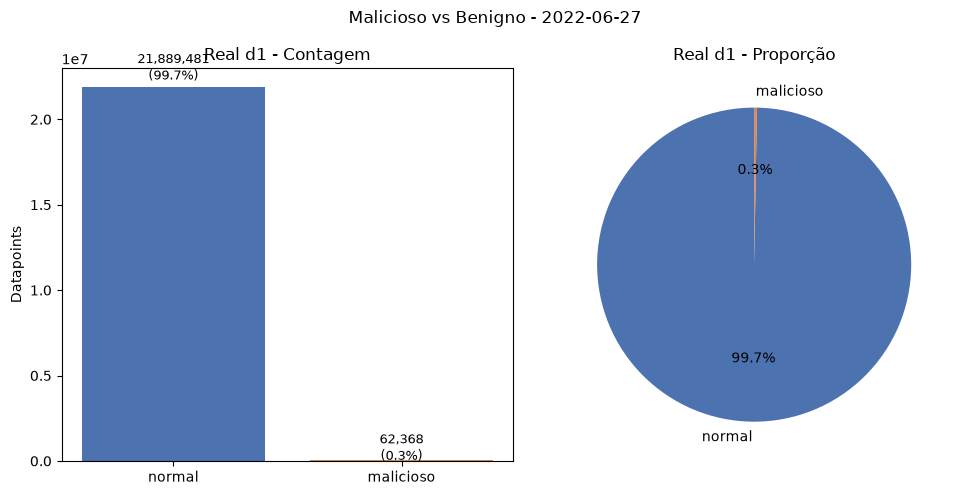

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = ['normal', 'malicioso']
colors = ['#4c72b0', '#dd8452']

# contagens absolutas
axes[0].bar(labels, real_df_d1_label_split['n'], color=colors)
axes[0].set_title('Real d1 - Contagem')
axes[0].set_ylabel('Datapoints')
for i, (n, pct) in enumerate(zip(real_df_d1_label_split['n'], real_df_d1_label_split['pct'])):
    axes[0].text(i, n * 1.02, f'{n:,}\n({pct:.1f}%)', ha='center', fontsize=9)

# proporção
axes[1].pie(real_df_d1_label_split['n'], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Real d1 - Proporção')

plt.suptitle('Malicioso vs Benigno - 2022-06-27')
plt.tight_layout()
plt.savefig('Comiset23_Real_Dataset/real_d1_label_split.png', dpi=150, bbox_inches='tight')
plt.show()

### Resumo da fatia cortada

In [50]:
df_d1_summary = conn.sql("""
    SELECT
        COUNT(*)                                                                    AS total,
        COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NOT NULL)            AS maliciosos,
        COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NULL)                AS benignos,
        round(100.0 * COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NOT NULL) / COUNT(*), 3) AS pct_malicioso,
        round(100.0 * COUNT(*) FILTER (WHERE _source['rule_technique_id'] IS NULL) / COUNT(*), 3)     AS pct_normal,
        MIN(strptime(trim('"' FROM _source['@timestamp']::VARCHAR), '%Y-%m-%dT%H:%M:%S.%gZ')) AS ts_inicio,
        MAX(strptime(trim('"' FROM _source['@timestamp']::VARCHAR), '%Y-%m-%dT%H:%M:%S.%gZ')) AS ts_fim
    FROM 'Comiset23_Real_Dataset/real_d1.parquet'
""").df()

df_d1_summary['total_fmt']      = df_d1_summary['total'].apply(lambda x: f"{x:,}")
df_d1_summary['maliciosos_fmt'] = df_d1_summary['maliciosos'].apply(lambda x: f"{x:,}")
df_d1_summary['benignos_fmt']   = df_d1_summary['benignos'].apply(lambda x: f"{x:,}")

df_d1_summary.T.to_csv('Comiset23_Real_Dataset/real_d1_summary.csv', index=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [51]:
df_d1_summary.T

,0
total,21951849
maliciosos,62368
benignos,21889481
pct_malicioso,0.28
pct_normal,99.72
ts_inicio,2022-06-27 05:47:17.940000
ts_fim,2022-06-27 19:47:06.245000
total_fmt,"21,951,849"
maliciosos_fmt,"62,368"
benignos_fmt,"21,889,481"


---

# Fim